y: 227
y: 316
y: 405
y: 494
y: 583
y: 672
y: 761
y: 850


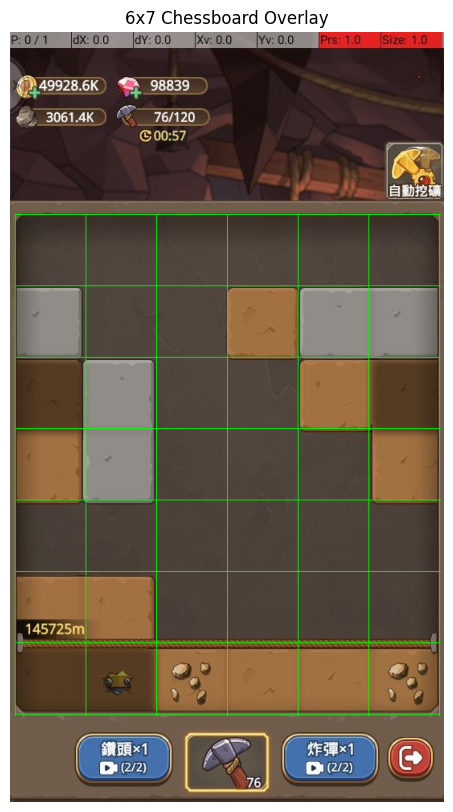

In [ ]:
import cv2
import numpy as np
img = cv2.imread(r'A:\main4_1746057661.705409.jpg')
import matplotlib.pyplot as plt

# 讀取圖片

# 棋盤區域設定（左上角和右下角座標）
top_left = (6, 227)
bottom_right = (535, 852)

# 棋盤尺寸：6列 × 7行（columns × rows）
cols, rows = 6, 7

# 計算格子大小
cell_width = int(round(bottom_right[0] - top_left[0]) / cols)
cell_height = int(round(bottom_right[1] - top_left[1]) / rows)

# 畫出橫線與直線
for i in range(rows + 1):
    y = int(top_left[1] + i * cell_height)
    print(f"y: {y}")
    cv2.line(img, (top_left[0], y), (bottom_right[0], y), (0, 255, 0), 1)

for j in range(cols + 1):
    x = int(top_left[0] + j * cell_width)
    cv2.line(img, (x, top_left[1]), (x, bottom_right[1]), (0, 255, 0), 1)

# 顯示圖像（使用 Matplotlib 因為 OpenCV imshow 不適用於非本地環境）
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 10))
plt.imshow(img_rgb)
plt.axis('off')
plt.title("6x7 Chessboard Overlay")
plt.show()


In [128]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import uiautomator2 as u2
import time
# 讀取圖片
d = u2.connect('emulator-5562')
# img = d.screenshot(format='opencv')
# cv2.imshow('screenshot', img)
# cv2.waitKey(0)
xlist=[41,176,222,312,401,487]
test=0
while True:
    img = d.screenshot(format='opencv')
    # 棋盤左上與右下角位置
    top_left = (6, 227)
    bottom_right = (535, 852)

    # 棋盤設定：6 列 × 7 行（cols × rows）
    cols, rows = 6, 7

    # 計算每格大小（四捨五入並強制整數）
    cell_width = int(round((bottom_right[0] - top_left[0]) / cols))
    cell_height = int(round((bottom_right[1] - top_left[1]) / rows))

    # 建立輸出資料夾
    output_dir = "extracted_cells"
    os.makedirs(output_dir, exist_ok=True)

    # 逐格裁切並儲存
    for row in range(rows):
        for col in range(cols):
            x1 = top_left[0] + col * cell_width
            y1 = top_left[1] + row * cell_height
            x2 = x1 + cell_width
            y2 = y1 + cell_height

            cell = img[y1:y2, x1:x2]
            filename = f"{output_dir}/cell_r{row}_c{col}{time.time()}.png"
            cv2.imwrite(filename, cell)

    print(f"✅ All {rows * cols} cells saved to '{output_dir}'")
    d.click(312,798)
    time.sleep(3)


✅ All 42 cells saved to 'extracted_cells'


KeyboardInterrupt: 

In [ ]:
import heapq, copy
# ----------------- 基本設定 -----------------
H, W = 7, 6
TREASURE_BASE = {'gold', 'silver', 'copper', 'skill', 'partner'}
TREASURES = TREASURE_BASE | {f'dis_{t}' for t in TREASURE_BASE}

HARDNESS = {'dirt': 1, 'rock': 2, 'one-step-rock': 1,
            'copper': 1, 'silver': 1, 'gold': 1,
            'skill': 1, 'partner': 1}
SCORE = {'copper': 750, 'silver': 800, 'gold': 3000, 'skill': 500, 'partner': 500}

def in_bounds(y, x): return 0 <= y < H and 0 <= x < W
DIR4 = [(-1, 0), (1, 0), (0, -1), (0, 1)]
def cost_of(cell):  return HARDNESS.get(cell, 1)
def score_of(cell): return SCORE.get(cell, 0)
UNLOCK_BONUS = 200      # 打通「斷線寶物」給的額外分數
def unlock_gain(grid, x, y, already_unlocked):
    """若在 (x,y) 變成 'e'，可一次性解鎖多少 dis_*？"""
    gain = 0
    newly = set()
    for dy, dx in DIR4:
        nx, ny = x+dx, y+dy
        if not in_bounds(ny, nx):
            continue
        cell = grid[ny][nx]
        if cell.startswith('dis_') and (nx, ny) not in already_unlocked:
            base = cell[4:]                     # 'dis_copper' → 'copper'
            gain += UNLOCK_BONUS + SCORE.get(base, 0)
            newly.add((nx, ny))
    return gain, newly

# -------------------------------------------------
def find_multi_paths(grid, beam_k=10, max_len=5):
    """
    回傳 (best_path, best_net_value)
    best_path  : [(x,y)...] 依序要挖的座標
    best_value : 總工具成本 - 總寶物得分   （越小越好）
    """
    best_path   = None
    best_value  = float('inf')

    # ---------- 初始節點：所有與 'e' 相鄰、需挖掘的方塊 ----------
    open_q = []
    for y in range(H):
        for x in range(W):
            if grid[y][x] == 'e':
                continue
            if not any(in_bounds(y+dy, x+dx) and grid[y+dy][x+dx] == 'e'
                       for dy, dx in DIR4):
                continue   # 不鄰接空格，不能作為第一鎚
            cost  = cost_of(grid[y][x])
            score = score_of(grid[y][x])
            treasures = {(x, y)} if grid[y][x] in TREASURES else set()
            net   = cost - score
            state = (net, cost, score, (x, y), treasures, [(x, y)])
            heapq.heappush(open_q, state)

    # ---------- Beam / Best-First 展開 ----------
    for _ in range(max_len - 1):          # 已經花 1 步；還能再展開 max_len-1 步
        new_q = []
        while open_q:
            net, cost, score, (cx, cy), ts, path = heapq.heappop(open_q)

            # 先更新目前最佳
            if net < best_value:
                best_value, best_path = net, path

        # ---------- 向四鄰擴張 ----------
        for dy, dx in DIR4:
            nx, ny = cx + dx, cy + dy
            if not in_bounds(ny, nx):
                continue
            if (nx, ny) in path or grid[ny][nx] == 'e':
                continue       # 已走過或本來就是空洞

            cell = grid[ny][nx]

            # --- 成本與基本得分 ---
            cost_inc  = cost_of(cell)
            score_inc = score_of(cell) if cell in TREASURES and (nx, ny) not in ts else 0

            # --- ⬇️  【重點】計算打通後的解鎖收益 ------------
            unlock_inc, newly = unlock_gain(grid, nx, ny, ts)

            new_cost  = cost + cost_inc
            new_score = score + score_inc + unlock_inc
            new_ts    = ts | newly
            if score_inc > 0:
                new_ts.add((nx, ny))     # 把自己也標成已拿

            new_net  = new_cost - new_score
            new_path = path + [(nx, ny)]
            new_state = (new_net, new_cost, new_score, (nx, ny), new_ts, new_path)
            heapq.heappush(new_q, new_state)

        # Beam 裁剪：只保留淨效用最小的前 beam_k 條
        open_q = heapq.nsmallest(beam_k, new_q)
        if not open_q: break

    # 最後再更新一次（避免 max_len = 1 的情況）
    for s in open_q:
        if s[0] < best_value:
            best_value, best_path = s[0], s[-1]

    return best_path, best_value
# -------------------------------------------------

# ---------- 示範棋盤（把 (4,6) 改成真正的 copper 看效果） ----------
board = [
    ['e','e','e','e','rock','e'],
    ['rock','rock','e','dirt','dis_e','dirt'],
    ['rock','e','e','rock','dis_dirt','dis_rock'],
    ['dis_dirt','dirt','e','dirt','dis_dirt','dis_dirt'],
    ['dirt','e','e','dirt','dis_dirt','dis_dirt'],
    ['dis_dirt','rock','e','rock','dis_rock','dis_dirt'],
    ['dis_dirt','dis_partner','rock','dis_dirt','dis_copper','dis_rock']  # ★ (4,6) → copper
]

best, val = find_multi_paths(board, beam_k=12, max_len=4)
if best:
    print(">> 推薦路徑 (總步數 ≤ 4)：")
    for i, (x, y) in enumerate(best, 1):
        print(f"  Step {i}: dig ({x},{y}) -> {board[y][x]}")
    print("淨效用 (工具成本 - 寶物得分):", val)
else:
    print(">> 在 4 步內找不到更好的挖礦策略")


>> 推薦路徑 (總步數 ≤ 4)：
  Step 1: dig (4,0) -> rock
  Step 2: dig (4,1) -> dis_e
  Step 3: dig (4,2) -> dis_dirt
淨效用 (工具成本 - 寶物得分): -796


In [ ]:
import cv2, copy, heapq
import torch, torch.nn.functional as F
from torchvision import transforms
import numpy as np
from PIL import Image
from itertools import count
from typing import List, Tuple
from simplecnn import SimpleCNN
class MiningPlanner:
    # ---- 常數（可依實際遊戲再調）----
    H, W = 7, 6                                 # 棋盤格數 y, x
    TREASURE_BASE = {'gold','silver','copper','skill','partner'}
    TREASURES = TREASURE_BASE | {f'dis_{t}' for t in TREASURE_BASE}
    HARDNESS = {'dirt':1,'rock':2,'one-step-rock':1,
                'copper':1,'silver':1,'gold':1,'skill':1,'partner':1}
    SCORE = {'copper':750,'silver':800,'gold':3000,'skill':500,'partner':500}
    UNLOCK_BONUS = 200
    DIR4 = [(-1,0),(1,0),(0,-1),(0,1)]
    uid = count()                  # for heap tie-break
    # ----------------- 估價函式 -----------------
    def cost_of(self,cell): return self.HARDNESS.get(cell,1)
    def score_of(self,cell): return self.SCORE.get(cell,0)

    # ---- 初始化 ----
    def __init__(self,
                 model: torch.nn.Module,
                 transform,
                 class_names: List[str],
                 board_lt: Tuple[int,int],        # 影像左上格 (x,y)
                 board_rb: Tuple[int,int],        # 影像右下格 (x,y)
                 device='cpu'):
        self.model = model.to(device)
        self.model.eval()
        self.tr = transform
        self.class_names = class_names
        self.lt = board_lt
        self.rb = board_rb
        self.device = device

        # 預算 / beam 參數可外調
        self.beam_k = 6
        self.max_len = 3

    # ---- 工具函式 ----
    @staticmethod
    def in_bounds(y,x): return 0<=y<MiningPlanner.H and 0<=x<MiningPlanner.W

    # -------- 1. 影像 → 7×6 類別矩陣 --------


    def find_paths(self,grid, beam_k=6, max_len=4):

        best_path = None
        best_value = float('inf')        # A*用「越小越好」

        # 搜尋所有寶物作為終點
        for y in range(self.H):
            for x in range(self.W):
                cell = grid[y][x]
                if cell not in self.TREASURES: continue
                target_score = self.score_of(cell)

                # open: (F, G, path), path = list[(x,y)]
                open_q = []
                # 從寶物出發：G=0 (已不需挖寶物本身)，H=曼哈頓距離估成本
                heapq.heappush(open_q, (0, 0, [(x,y)]))

                for depth in range(max_len):
                    new_q = []
                    while open_q:
                        F, G, path = heapq.heappop(open_q)
                        cx, cy = path[-1]
                        # 若已到相鄰 e，形成完整路徑
                        if any(self.in_bounds(cy+dy,cx+dx) and grid[cy+dy][cx+dx]=='e'
                            for dy,dx in self.DIR4):
                            if depth<=max_len-1:
                                total_cost = G          # 目前累積的工具成本
                                net = total_cost - target_score
                                if net < best_value:
                                    best_value = net
                                    best_path = list(reversed(path)) # 反向→自 e 到寶物
                            continue

                        # 延伸鄰接可挖方塊
                        for dy,dx in self.DIR4:
                            ny,nx = cy+dy, cx+dx
                            if not self.in_bounds(ny,nx):  continue
                            nxt = grid[ny][nx]
                            if nxt=='e' or nxt.startswith('dis_'): continue
                            if (nx,ny) in path: continue
                            g_cost = G + self.cost_of(nxt)
                            h_cost = 0  # 深度≤3，小圖可設0；或設估價距離
                            heapq.heappush(new_q, (g_cost+h_cost, g_cost, path+[(nx,ny)]))

                    # Beam 裁剪
                    open_q = heapq.nsmallest(beam_k, new_q)
                    if not open_q: break

        return best_path, best_value


    # -------- 4. 對外主函式 --------
    def plan(self, img_path:str):
        board=self.classify_board(img_path)
        path,val=self.find_paths(board,self.beam_k,self.max_len)
        return board,path,val

class_names = ["boom",
"copper",
"dirt",
"dis_boom",
"dis_coper",
"dis_dirt",
"dis_drill",
"dis_e",
"dis_gold",
"dis_partenr",
"dis_rock",
"dis_rube",
"dis_silver",
"dis_skill",
"drill",
"e",
"gold",
"one-step-rock",
"partner",
"rock",
"rube",
"silver",
"skill",]
# ======== 圖像前處理 ========
img_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
])
if __name__ == "__main__":
    top_left = (6, 227)
    bottom_right = (535, 852)
    simpleCNN = SimpleCNN(num_classes=len(class_names))
    # 假設你已經有 trained_model, img_transform, class_names
    trained_model = simpleCNN
    trained_model.load_state_dict(torch.load(r"A:\菇勇者全自動掛機\miner\oralce_model.pth"))
    trained_model.eval()
    planner = MiningPlanner(trained_model, img_transform, class_names,
                                board_lt=top_left, board_rb=bottom_right, device='cuda')
    board, moves, value = planner.plan("A:/main3_1746086766.9355874.jpg")
    print("分類矩陣:")
    for r in board: print(r)


    if moves:
        print("\n推薦行動序列:")
        for i,a in enumerate(moves,1):
            print(f"Step{i}: {a['type']}→{a['origin']}  cost={a['cost']} gain={a['score']}")
        print("淨效用:", value)
    else:
        print("無 3 步內路徑，建議挖底層捲動")

ModuleNotFoundError: No module named 'simplecnn'

In [ ]:
import cv2
import copy
import heapq
import torch
import torch.nn.functional as F
from torchvision import transforms
import numpy as np
from PIL import Image
from itertools import count
from typing import List, Tuple
# from miner.simplecnn import SimpleCNN
import os
import json
from datetime import datetime
from collections import defaultdict
import random
from typing import Union


class MiningPlanner:
    # ---- 常數（依實際遊戲可再調）----
    H, W = 7, 6
    DIS_TO_BASE = {f'dis_{t}': t for t in [
    'gold', 'silver', 'copper', 'skill', 'partner']}
                             # 棋盤格數  (y, x)
    tr = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ])
    TREASURE_BASE = {'gold', 'silver', 'copper', 'skill', 'partner'}
    TREASURES = TREASURE_BASE | {f'dis_{t}' for t in TREASURE_BASE}

    HARDNESS = {'dirt': 1, 'rock': 2, 'one-step-rock': 1,
                'copper': 1, 'silver': 1, 'gold': 1,
                'skill': 1, 'partner': 1}

    SCORE = {'copper': 750, 'silver': 800, 'gold': 3000,
             'skill': 500, 'partner': 500}
    top_left = (6, 227)
    bottom_right = (535, 852)
    # ---- 新增：讓 dis_* 也有殘值（這一行就夠）----
    SCORE.update({f'dis_{t}': 50 for t in TREASURE_BASE})
    class_names = ["boom",
                   "copper",
                   "dirt",
                   "dis_boom",
                   "dis_copper",
                   "dis_dirt",
                   "dis_drill",
                   "dis_e",
                   "dis_gold",
                   "dis_partner",
                   "dis_rock",
                   "dis_rube",
                   "dis_silver",
                   "dis_skill",
                   "drill",
                   "e",
                   "gold",
                   "one-step-rock",
                   "partner",
                   "rock",
                   "rube",
                   "silver",
                   "skill",]
    UNLOCK_BONUS = 200
    DIR4 = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    uid = count()                  # for heap tie-break
    # ----------------- 估價函式 -----------------
    def cost_of(self, cell): return self.HARDNESS.get(cell, 1)
    def score_of(self, cell): return self.SCORE.get(cell, 0)

    # ---- 初始化 ----
    def __init__(self,
                 model: torch.nn.Module,
                 board_lt: Tuple[int, int] = (6, 227),        # 影像左上格 (x,y)
                 board_rb: Tuple[int, int] = (535, 852),        # 影像右下格 (x,y)
                 device='cpu'):
        self.model = model.to(device)
        self.model.eval()
        self.lt = board_lt
        self.rb = board_rb
        self.device = device

        # 預算 / beam 參數可外調
        self.beam_k = 30
        self.max_len = 5
        self.cell_w = int(round((self.rb[0] - self.lt[0]) / self.W))
        self.cell_h = int(round((self.rb[1] - self.lt[1]) / self.H))
    # ---- 工具函式 ----
    @staticmethod
    def in_bounds(
        y, x): return 0 <= y < MiningPlanner.H and 0 <= x < MiningPlanner.W
    # -------- 訓練資料記錄 --------

    def save_training_example(self, board, actions, value, output_file="train_data.jsonl", image_path=None):
        example = {
            "timestamp": datetime.now().isoformat(),
            "board": board,
            "actions": actions,
            "value": value,
        }
        if image_path is not None and isinstance(image_path, (str, np.str_)):
            example["image_path"] = image_path
            example["board_id"] = os.path.basename(image_path)
        with open(output_file, 'a', encoding='utf-8') as f:
            f.write(json.dumps(example, ensure_ascii=False) + "\n")
    # -------- 1. 影像 → 7×6 類別矩陣 --------
    # def classify_board(self, img_path: str) -> List[List[str]]:
    # 圖片格式可能是路徑或陣列

    def classify_board(self, img: Union[str, np.ndarray]) -> List[List[str]]:
        if isinstance(img, str):
            img = cv2.imread(img)
        x0, y0 = self.lt
        x1, y1 = self.rb
        cell_w = int(round((x1-x0)/MiningPlanner.W))
        cell_h = int(round((y1-y0)/MiningPlanner.H))

        board = []
        for r in range(MiningPlanner.H):
            row = []
            for c in range(MiningPlanner.W):
                cx0 = x0 + c*cell_w
                cy0 = y0 + r*cell_h
                cell = img[cy0:cy0+cell_h, cx0:cx0+cell_w]
                cell_pil = Image.fromarray(
                    cv2.cvtColor(cell, cv2.COLOR_BGR2RGB))
                tensor = self.tr(cell_pil).unsqueeze(0).to(self.device)
                with torch.no_grad():
                    out = self.model(tensor)
                    prob = F.softmax(out, 1)
                    conf, pred = torch.max(prob, 1)
                label = "unknown" if conf.item(
                ) < 0.75 else self.class_names[pred.item()]
                row.append(label)
            board.append(row)
        return board

    def find_paths_with_free_walk(self, grid, max_dig=4):
        best_val, best_moves = float('inf'), None

        # 1️⃣ 所有 e 空格都能當起點
        start_cells = [(x, y) for y in range(self.H)
                       for x in range(self.W) if grid[y][x] == 'e']

        for sx, sy in start_cells:
            stack = [([(sx, sy)],          # path
                      0, 0,                # cost, score
                      0,                   # dig_cnt
                      set())]              # tset (挖到的寶物座標)

            while stack:
                path, cost, score, digs, tset = stack.pop()

                # 更新最佳
                net = cost - score
                if net < best_val:
                    best_val, best_moves = net, path

                # 已達挖掘上限就只能「走 e」，不能再挖
                cx, cy = path[-1]
                for dx, dy in self.DIR4:
                    nx, ny = cx + dx, cy + dy
                    if not self.in_bounds(ny, nx) or (nx, ny) in path:
                        continue

                    cell = grid[ny][nx]

                    if cell == 'e':
                        # 走空格：完全免費，也不增加 dig_cnt
                        stack.append(
                            (path + [(nx, ny)], cost, score, digs, tset))
                    else:
                        if digs >= max_dig:
                            continue            # 挖掘次數已滿
                        ncost = cost + self.cost_of(cell)
                        nscore = score
                        ntset = tset.copy()
                        if cell in self.TREASURES and (nx, ny) not in ntset:
                            nscore += self.score_of(cell)
                            ntset.add((nx, ny))
                        stack.append(
                            (path + [(nx, ny)], ncost, nscore, digs + 1, ntset))

        # ---- 把「挖掘步」抽出來回傳 ----
        if best_moves is None:
            # 先檢查最底層是否有可通的 'e'
            bottom_row = self.H - 1
            valid_e_positions = [(x, bottom_row) for x in range(self.W) if grid[bottom_row][x] == 'e']

            if not valid_e_positions:
                # 1️⃣ 沒有 'e' 連通到底層
                best_val = float('inf')
                best_moves = None

                # 從最底層往上查找是否有可以連通的格子
                for y in range(self.H - 2, -1, -1):  # 從倒數第二行開始往上掃
                    for x in range(self.W):
                        if grid[y][x] == 'e':
                            # 嘗試尋找可通的格子
                            for dx, dy in self.DIR4:
                                nx, ny = x + dx, y + dy
                                if self.in_bounds(ny, nx) and grid[ny][nx] != 'e':
                                    path = self.simple_path(grid, (nx, ny), (bottom_row, x))
                                    if path:
                                        cost = sum(self.cost_of(grid[py][px]) for px, py in path if grid[py][px] != 'e')
                                        if cost < best_val:
                                            best_val = cost
                                            best_moves = path

                if best_moves is None:
                    # 2️⃣ 全盤掃描：如果完全沒有有效通路，直接選擇代價最低的格子進行挖掘
                    min_cost = float('inf')
                    min_pos = None
                    for y in range(self.H):
                        for x in range(self.W):
                            if grid[y][x] == 'e':
                                continue
                            c = self.cost_of(grid[y][x])
                            if c < min_cost:
                                min_cost = c
                                min_pos = (x, y)
                    # 兜底：直接挖這一格
                    best_moves = [min_pos]
                    best_val = min_cost  # cost - score (score=0)

        # 最後組出 moves list
        digs_only = [p for p in best_moves if grid[p[1]][p[0]] != 'e']
        moves = [
            {
            'type': 'dig',
            'origin': p,
            'cost': self.cost_of(grid[p[1]][p[0]]),
            'score': self.score_of(grid[p[1]][p[0]])
            }
            for p in digs_only
        ]
        return moves, best_val


    # -------- 4. 對外主函式 --------
    def board_to_image_coords(self, x: int, y: int, offset=(0, 0)) -> Tuple[int, int]:
        img_x = self.lt[0] + x * self.cell_w + offset[0]
        img_y = self.lt[1] + y * self.cell_h + offset[1]
        return img_x, img_y
    def plan(self, img_path: str, save_to: str = None,image_path=None) -> Tuple[List[List[str]], List[dict], float]:
        board = self.classify_board(img_path)
        moves, val = self.find_paths_with_free_walk(board, max_dig=4)
        if save_to:
            self.save_training_example(
                board, moves, val, output_file=save_to, image_path=img_path,)
        return board, moves, val




# ======== 圖像前處理 ========

if __name__ == "__main__":
    # import uiautomator2 as u2
    import time
    import random
    from simplecnn import SimpleCNN

    simpleCNN = SimpleCNN(num_classes=23)
    # 假設你已經有 trained_model, img_transform, class_names
    trained_model = simpleCNN
    trained_model.load_state_dict(torch.load(
        r"A:\菇勇者全自動掛機\miner\oralce_model.pth"))
    trained_model.eval()
    planner = MiningPlanner(trained_model,
                            device='cuda')
    d= u2.connect('emulator-5554')
    img = d.screenshot(format='opencv')
    board, moves, value = planner.plan(img)
    print("分類矩陣:")
    for r in board:
        print(r)

    if moves:
        # print("\n推薦行動序列:")
        # for i, a in enumerate(moves, 1):
        #     print(
        #         f"Step{i}: {a['type']}→{a['origin']}  cost={a['cost']} gain={a['score']}")
        # print("淨效用:", value)
        img=cv2.imread("A:/main3_1746086766.9355874.jpg")

        for move in moves:
            x, y = move["origin"]
            img_x, img_y = planner.board_to_image_coords(x, y, offset=(44, 44))
            print(f"Dig at board ({x},{y}) → image pixel ({img_x},{img_y})")
            cv2.circle(img, (img_x, img_y), 20, (0, 255, 255), -1)
            cv2.imshow("Digging Path", img)
            cv2.waitKey(0)
    else:
        print("無 3 步內路徑，建議挖底層捲動")


ModuleNotFoundError: No module named 'simplecnn'

In [ ]:
import cv2
import copy
import heapq
import torch
import torch.nn.functional as F
from torchvision import transforms
import numpy as np
from PIL import Image
from itertools import count
from typing import List, Tuple
# from miner.simplecnn import SimpleCNN
import os
import json
from datetime import datetime
from collections import defaultdict
import random
from typing import Union


class MiningPlanner:
    # ---- 常數（依實際遊戲可再調）----
    H, W = 7, 6
    DIS_TO_BASE = {f'dis_{t}': t for t in [
    'gold', 'silver', 'copper', 'skill', 'partner', 'drill', 'boom']}
                             # 棋盤格數  (y, x)
    tr = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ])
    TREASURE_BASE = {'gold', 'silver', 'copper', 'skill', 'partner','drill','boom'}
    TREASURES = TREASURE_BASE | {f'dis_{t}' for t in TREASURE_BASE}

    HARDNESS = {'dirt': 1, 'rock': 2, 'one-step-rock': 1,
                'copper': 1, 'silver': 1, 'gold': 1,
                'skill': 1, 'partner': 1,'drill':1,'boom':1,'e':0}

    SCORE = {'copper': 750, 'silver': 800, 'gold': 3000,
             'skill': 500, 'partner': 500,'drill':1000,'boom':1000,}
    top_left = (6, 227)
    bottom_right = (535, 852)
    # ---- 新增：讓 dis_* 也有殘值（這一行就夠）----
    SCORE.update({f'dis_{t}': 50 for t in TREASURE_BASE})
    class_names = ["boom",
                   "copper",
                   "dirt",
                   "dis_boom",
                   "dis_copper",
                   "dis_dirt",
                   "dis_drill",
                   "dis_e",
                   "dis_gold",
                   "dis_partner",
                   "dis_rock",
                   "dis_rube",
                   "dis_silver",
                   "dis_skill",
                   "drill",
                   "e",
                   "gold",
                   "one-step-rock",
                   "partner",
                   "rock",
                   "rube",
                   "silver",
                   "skill",]
    UNLOCK_BONUS = 200
    DIR4 = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    uid = count()                  # for heap tie-break
    # ----------------- 估價函式 -----------------
    def cost_of(self, cell): return self.HARDNESS.get(cell, 1)
    def score_of(self, cell): return self.SCORE.get(cell, 0)

    # ---- 初始化 ----
    def __init__(self,
                 model: torch.nn.Module,
                 board_lt: Tuple[int, int] = (6, 227),        # 影像左上格 (x,y)
                 board_rb: Tuple[int, int] = (535, 852),        # 影像右下格 (x,y)
                 device='cpu'):
        self.model = model.to(device)
        self.model.eval()
        self.lt = board_lt
        self.rb = board_rb
        self.device = device

        # 預算 / beam 參數可外調
        self.beam_k = 30
        self.max_len = 5
        self.cell_w = int(round((self.rb[0] - self.lt[0]) / self.W))
        self.cell_h = int(round((self.rb[1] - self.lt[1]) / self.H))
    # ---- 工具函式 ----
    @staticmethod
    def in_bounds(
        y, x): return 0 <= y < MiningPlanner.H and 0 <= x < MiningPlanner.W
    # -------- 訓練資料記錄 --------

    def save_training_example(self, board, actions, value, output_file="train_data.jsonl", image_path=None):
        example = {
            "timestamp": datetime.now().isoformat(),
            "board": board,
            "actions": actions,
            "value": value,
        }
        if image_path is not None and isinstance(image_path, (str, np.str_)):
            example["image_path"] = image_path
            example["board_id"] = os.path.basename(image_path)
        with open(output_file, 'a', encoding='utf-8') as f:
            f.write(json.dumps(example, ensure_ascii=False) + "\n")
    # -------- 1. 影像 → 7×6 類別矩陣 --------
    # def classify_board(self, img_path: str) -> List[List[str]]:
    # 圖片格式可能是路徑或陣列

    def classify_board(self, img: Union[str, np.ndarray]) -> List[List[str]]:
        if isinstance(img, str):
            img = cv2.imread(img)
        x0, y0 = self.lt
        x1, y1 = self.rb
        cell_w = int(round((x1-x0)/MiningPlanner.W))
        cell_h = int(round((y1-y0)/MiningPlanner.H))

        board = []
        for r in range(MiningPlanner.H):
            row = []
            for c in range(MiningPlanner.W):
                cx0 = x0 + c*cell_w
                cy0 = y0 + r*cell_h
                cell = img[cy0:cy0+cell_h, cx0:cx0+cell_w]
                cell_pil = Image.fromarray(
                    cv2.cvtColor(cell, cv2.COLOR_BGR2RGB))
                tensor = self.tr(cell_pil).unsqueeze(0).to(self.device)
                with torch.no_grad():
                    out = self.model(tensor)
                    prob = F.softmax(out, 1)
                    conf, pred = torch.max(prob, 1)
                label = "unknown" if conf.item(
                ) < 0.75 else self.class_names[pred.item()]
                row.append(label)
            board.append(row)
        return board

    def find_paths_with_free_walk(self, grid, max_dig=4):
        best_val, best_moves = float('inf'), None

        # 1️⃣ 所有 e 空格都能當起點
        start_cells = [(x, y) for y in range(self.H)
                    for x in range(self.W) if grid[y][x] == 'e']

        # ------------------------------------------------------------------
        for sx, sy in start_cells:
            stack = [([(sx, sy)], 0, 0, 0, set())]   # path, cost, score, digs, tset

            while stack:
                path, cost, score, digs, tset = stack.pop()

                net = cost - score
                if net < best_val:
                    best_val, best_moves = net, path

                cx, cy = path[-1]
                for dx, dy in self.DIR4:
                    nx, ny = cx + dx, cy + dy
                    if not self.in_bounds(ny, nx) or (nx, ny) in path:
                        continue

                    cell = grid[ny][nx]

                    if cell == 'e':
                        stack.append((path + [(nx, ny)], cost, score, digs, tset))
                    else:
                        if digs >= max_dig:
                            continue
                        ncost  = cost + self.cost_of(cell)
                        nscore = score
                        ntset  = tset.copy()
                        if cell in self.TREASURES and (nx, ny) not in ntset:
                            nscore += self.score_of(cell)
                            ntset.add((nx, ny))
                        stack.append((path + [(nx, ny)],
                                    ncost, nscore, digs + 1, ntset))
        # ------------------------------------------------------------------
        # ⬇️ 這行開始才是「全部 DFS 結束後」的收尾 ========================
        digs_only = [p for p in (best_moves or []) if grid[p[1]][p[0]] != 'e']

        # ───── 新規則：如果還沒有任何可挖步驟 ──────
        if not digs_only:
            bottom = self.H - 1                       # 最底列 index

            # ❶ 最底列已有 e ⇒ 這回合不用挖
            if any(grid[bottom][x] == 'e' for x in range(self.W)):
                return [], 0

            # ❷ 從最底列挑 cost 最低的可挖格
            min_cost = float('inf')
            fallback = None
            for x in range(self.W):
                cell = grid[bottom][x]
                if cell == 'e' or cell.startswith('dis_'):
                    continue
                c = self.cost_of(cell)
                if c < min_cost:
                    min_cost, fallback = c, (x, bottom)

            # ❸ 整排都是 dis_* ⇒ 你要往上一列找、或直接回傳空
            if fallback is None:
                return [], float('inf')

            digs_only = [fallback]
            best_val  = min_cost                     # cost - score（score = 0）

        moves = [{
                'type'  : 'dig',
                'origin': p,
                'cost'  : self.cost_of(grid[p[1]][p[0]]),   # 單步花多少
                'score' : self.score_of(grid[p[1]][p[0]]),
                'repeat': self.cost_of(grid[p[1]][p[0]])    # 要敲幾下
            } for p in digs_only
            ]

        return moves, best_val



    # -------- 4. 對外主函式 --------
    def board_to_image_coords(self, x: int, y: int, offset=(0, 0)) -> Tuple[int, int]:
        img_x = self.lt[0] + x * self.cell_w + offset[0]
        img_y = self.lt[1] + y * self.cell_h + offset[1]
        return img_x, img_y
    def plan(self, img_path: str, save_to: str = None,image_path=None) -> Tuple[List[List[str]], List[dict], float]:
        board = self.classify_board(img_path)
        moves, val = self.find_paths_with_free_walk(board, max_dig=4)
        if save_to:
            self.save_training_example(
                board, moves, val, output_file=save_to, image_path=img_path,)
        return board, moves, val

resize_size = (64, 64)
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * (resize_size[0]//4) * (resize_size[1]//4), 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # -> 16x64x64
        x = self.pool(F.relu(self.conv2(x)))  # -> 32x32x32
        x = x.view(x.size(0), -1)             # 展平成向量
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# ======== 圖像前處理 ========
if __name__ == "__main__":
    import time
    import random

    simpleCNN = SimpleCNN(num_classes=23)
    # 假設你已經有 trained_model, img_transform, class_names
    trained_model = simpleCNN
    trained_model.load_state_dict(torch.load(
        r"A:\菇勇者全自動掛機\miner\oralce_model.pth"))
    trained_model.eval()
    planner = MiningPlanner(trained_model,
                            device='cuda')
    img = cv2.imread(r"A:\recording/emulator-5554_1746802240175817.jpg")
    board, moves, value = planner.plan(img)
    print("分類矩陣:")
    for r in board:
        print(r)

    if moves:
        print("\n推薦行動序列:")
        for i, a in enumerate(moves, 1):
            print(
                f"Step{i}: {a['type']}→{a['origin']}  cost={a['cost']} gain={a['score']}")
        print("淨效用:", value)


    for move in moves:
        x, y = move["origin"]
        img_x, img_y = planner.board_to_image_coords(x, y, offset=(44, 44))
        print(f"Dig at board ({x},{y}) → image pixel ({img_x},{img_y})")
        cv2.circle(img, (img_x, img_y), 20, (0, 255, 255), -1)
        cv2.imshow("Digging Path", img)
        cv2.waitKey(0)
# if __name__ == "__main__":
#     import uiautomator2 as u2
#     import time
#     import random

#     simpleCNN = SimpleCNN(num_classes=23)
#     # 假設你已經有 trained_model, img_transform, class_names
#     trained_model = simpleCNN
#     trained_model.load_state_dict(torch.load(
#         r"A:\菇勇者全自動掛機\miner\oralce_model.pth"))
#     trained_model.eval()
#     planner = MiningPlanner(trained_model,
#                             device='cuda')
#     d= u2.connect('emulator-5554')
#     img = d.screenshot(format='opencv')
#     board, moves, value = planner.plan(img)
#     print("分類矩陣:")
#     for r in board:
#         print(r)

#     if moves:
#         # print("\n推薦行動序列:")
#         # for i, a in enumerate(moves, 1):
#         #     print(
#         #         f"Step{i}: {a['type']}→{a['origin']}  cost={a['cost']} gain={a['score']}")
#         # print("淨效用:", value)
#         img=cv2.imread("A:/main3_1746086766.9355874.jpg")

#         for move in moves:
#             x, y = move["origin"]
#             img_x, img_y = planner.board_to_image_coords(x, y, offset=(44, 44))
#             print(f"Dig at board ({x},{y}) → image pixel ({img_x},{img_y})")
#             cv2.circle(img, (img_x, img_y), 20, (0, 255, 255), -1)
#             cv2.imshow("Digging Path", img)
#             cv2.waitKey(0)
#     else:
#         print("無 3 步內路徑，建議挖底層捲動")


C:\Users\eric\AppData\Local\Temp\ipykernel_22920\811437457.py:266: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  trained_model.load_state_dict(torch.load(


分類矩陣:
['e', 'dirt', 'e', 'dirt', 'e', 'rock']
['e', 'rock', 'dirt', 'dirt', 'e', 'e']
['e', 'e', 'dirt', 'dis_rock', 'dirt', 'rock']
['e', 'e', 'e', 'copper', 'dis_partner', 'dis_dirt']
['e', 'e', 'e', 'dirt', 'dis_rock', 'dis_dirt']
['dirt', 'e', 'rock', 'dis_e', 'dis_rock', 'dis_dirt']
['dis_e', 'dirt', 'dis_copper', 'dis_dirt', 'dis_dirt', 'unknown']

推薦行動序列:
Step1: dig→(3, 3)  cost=1 gain=300
Step2: dig→(4, 3)  cost=1 gain=50
淨效用: -348
Dig at board (3,3) → image pixel (314,538)
Dig at board (4,3) → image pixel (402,538)


In [12]:
import json, collections, re

cnt_depth = [collections.Counter() for _ in range(7)]   # 7 列
raw_cnt    = collections.Counter()

with open(r'A:\recording\emulator-5554.jsonl', encoding='utf-8') as f:
    for line in f:
        j      = json.loads(line)
        board  = j['board']          # shape 7×6
        for y, row in enumerate(board):
            for cell in row:
                raw_cnt[cell] += 1
                if not cell.startswith('dis_'):        # 只統計「原生格」
                    cnt_depth[y][cell] += 1

# 把 dis_* 合併回 base 名
def strip_dis(cell):
    return re.sub(r'^dis_', '', cell)

total_raw   = sum(raw_cnt.values())
p_global    = {c: raw_cnt[c]/total_raw for c in raw_cnt}

p_depth = []
for y in range(7):
    s = sum(cnt_depth[y].values()) or 1
    p = {c: cnt_depth[y][c]/s for c in cnt_depth[y]}
    p_depth.append(p)


In [13]:
import random
CELL_TYPES = list(p_global.keys())

def sample_cell(p_dict):
    cells, probs = zip(*p_dict.items())
    return random.choices(cells, probs)[0]

def gen_board(layered=True):
    board=[]
    for y in range(7):
        row=[]
        for _ in range(6):
            if layered and p_depth[y]:   # 有分層分佈
                row.append(sample_cell(p_depth[y]))
            else:                        # 用整體分佈
                row.append(sample_cell(p_global))
        board.append(row)
    # 保證最頂一列沒有 dis_*
    board[0] = [strip_dis(c) for c in board[0]]
    return board


In [28]:
teacher_planner = MiningPlanner(trained_model, device='cuda')

def teacher_plan(board, beam_k=30):
    """
    board : list[list[str]]  7×6
    回傳 moves, val ── 直接沿用 MiningPlanner.find_paths_with_free_walk
    """
    # MiningPlanner.plan() 需要影像；我們有 board → 直接呼叫內部函式
    moves, val = teacher_planner.find_paths_with_free_walk(board, max_dig=3)
    return moves, val

In [18]:
def fallback_greedy(board):
    """
    挑 cost 最低的可挖格；沒有就隨機
    """
    best = None
    for y in range(7):
        for x in range(6):
            cell = board[y][x]
            if cell.startswith('dis_') or cell == 'e':
                continue
            c = HARDNESS[cell]
            if best is None or c < best[2]:
                best = (x, y, c)
    if best:
        return best[0], best[1]
    # 若整盤只有 e／dis_e，隨機一格
    return random.randint(0,5), random.randint(0,6)
HARDNESS = teacher_planner.HARDNESS   # ← 加在腳本最前面
SCORE    = teacher_planner.SCORE
def gen_board(layered=True):
    board=[]
    for y in range(7):
        row=[]
        for _ in range(6):
            if layered and p_depth[y]:   # 有分層分佈
                row.append(sample_cell(p_depth[y]))
            else:                        # 用整體分佈
                row.append(sample_cell(p_global))
        board.append(row)
    # 保證最頂一列沒有 dis_*
    board[0] = [strip_dis(c) for c in board[0]]
    return board
# =========================================================
# 依你先前統計好的機率表（p_global / p_depth），先準備取樣工具
# =========================================================
import random

CELL_TYPES = list(p_global.keys())

def sample_cell(p_dict):
    cells, probs = zip(*p_dict.items())
    return random.choices(cells, probs)[0]

def gen_new_row():
    """產生最底一列──用最深那層的分佈；若沒分層就用全域分佈"""
    return [sample_cell(p_depth[-1] or p_global) for _ in range(6)]

# =========================================================
# ❶ board_copy : 深拷貝 7×6 清單
# =========================================================
def board_copy(board):
    return [row[:] for row in board]     # 簡單 list copy

# =========================================================
# ❷ reached_bottom_e : 判斷最底列是否出現「可通行空格」
#     這裡僅把 'e' 視為可通；若你要把 dis_e 也算進去，就改成 in ('e','dis_e')
# =========================================================
def reached_bottom_e(board):
    bottom_row = board[-1]
    return any(cell == 'e' for cell in bottom_row)

# =========================================================
# ❸ scroll_down : 當最底列打穿後，把整盤「上捲一列」並隨機生成新底列
# =========================================================
def scroll_down(board):
    """
    規則：刪掉最上面一列（index 0），剩下全部向上平移，
          再用 gen_new_row() 補一列在最底。
    """
    board.pop(0)                 # 移除最上排
    board.append(gen_new_row())  # 新的一排塞到底部


In [20]:
# -------------------------------------------
# 先確保有 MiningPlanner、teacher_plan、fallback_greedy
# （前一回合已示範，不再贅述）
# -------------------------------------------
def teacher_agent_step(board, digs_left):
    """
    你原有的老師演算法：
      board → 3-step beam → 選一格
    這裡只需 return (x,y) (0-based)
    """
    moves, _ = teacher_plan(board, beam_k=30)
    return moves[0]['origin'] if moves else fallback_greedy(board)
def rollout_once():
    board = gen_board()            # 7×6 起始盤面
    traj  = []
    for step in range(70):         # 70 把鎬子
        x, y = teacher_agent_step(board, 70 - step)
        cell = board[y][x]

        cost  = teacher_planner.cost_of(cell)
        gain  = teacher_planner.score_of(cell)
        reward = gain - cost

        traj.append({
            "obs"   : board_copy(board),    # 保留下決策當下的棋盤
            "action": y * 6 + x,            # 0~41
            "reward": reward
        })

        board[y][x] = 'e'                   # 挖成洞

        if reached_bottom_e(board):         # 如果底列被打穿
            scroll_down(board)              # 整盤向上捲 + 補新列
    return traj


In [21]:
test_board = [['e']*6 for _ in range(7)]
print(reached_bottom_e(test_board))  # ➜ True
scroll_down(test_board)
print(len(test_board))               # ➜ 7  (確保仍是 7 列)


True
7


In [29]:

def rollout_once():
    board = gen_board()
    traj  = []
    for step in range(70):                         # 70 鎬子
        x, y = teacher_agent_step(board, 70-step)
        cell  = board[y][x]
        if cell == 'unknown': 
            cell="e"                    # 這格已經挖過了
        cost  = HARDNESS[cell]
        gain  = SCORE.get(cell, 0)
        reward= gain - cost
        traj.append({
            "obs"   : board_copy(board),           # 深拷貝或 encode
            "action": y*6+x,
            "reward": reward
        })
        board[y][x] = 'e'
        if reached_bottom_e(board): scroll_down(board)
    return traj

with open('teacher_70step.jsonl', 'w', encoding='utf-8') as f:
    for _ in range(1000):                          # 1000 局
        traj = rollout_once()
        for t in traj:
            f.write(json.dumps(t, ensure_ascii=False)+'\n')


KeyError: 'e'

In [ ]:
#!/usr/bin/env python
# coding: utf-8
"""
train_miner.py  ‒  RL pipeline for the 6×7 mining game
======================================================

用法
----
$ python train_miner.py --teacher_file teacher_logs.jsonl \
                        --algo PPO \
                        --total_timesteps 200_000
"""
from __future__ import annotations
import argparse, json, random, itertools, os, sys
from pathlib import Path
from typing import List, Tuple, Dict
from stable_baselines3.common.policies import ActorCriticPolicy

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# ----------------------------------------------------------
# 0. 一些常數定義
# ----------------------------------------------------------
WIDTH, HEIGHT = 6, 7
LABELS = [                      # 23 + 1 ('unknown')
    "e","dirt","rock","one-step-rock",
    "copper","silver","gold","rube","skill","partner",
    "drill","boom","dis_boom","dis_drill",
    "dis_e","dis_dirt","dis_rock","dis_one-step-rock",
    "dis_copper","dis_silver","dis_gold","dis_rube",
    "dis_skill","dis_partner","unknown"
]
LBL2ID: Dict[str,int] = {lbl:i for i,lbl in enumerate(LABELS)}
ID2LBL: Dict[int,str] = {i:lbl for lbl,i in LBL2ID.items()}

TOOLS = ["pickaxe","bomb","drill"]               # 3 種工具
N_ACTIONS = len(TOOLS) * WIDTH * HEIGHT         # 3 × 42 = 126


# ----------------------------------------------------------
# 1. Gym 環境
# ----------------------------------------------------------
class MiningEnv(gym.Env):
    metadata = {"render.modes": ["human"]}
    
    def __init__(self, scroll_bonus: int = 50, max_steps: int = 200, rng_seed: int | None = None):
        super().__init__()
        self.scroll_bonus = scroll_bonus
        self.max_steps = max_steps
        self.rng = np.random.default_rng(rng_seed)

        # 機率表，總和應該 = 1.0
        self.spawn_dist = {
            "dirt":    0.3,
            "rock":    0.15,
            "e":       0.3,
            "skill":   0.05,
            "partner": 0.05,
            "copper":  0.06,
            "silver":  0.03,
            "gold":    0.01,
            "boom":    0.025,
            "drill":   0.025,
        }

        self.observation_space = spaces.Box(
            low=0, high=len(LABELS)-1,
            shape=(HEIGHT, WIDTH), dtype=np.uint8
        )
        self.action_space = spaces.Discrete(N_ACTIONS)
        self.reset()

    def _random_block(self, allow_ore: bool = False) -> str:
        """
        產生隨機新方塊（新增在最上面），
        根據 spawn_dist 中定義的機率抽樣，
        若 allow_ore=False 則先把礦石項目過濾掉再重算機率。
        """
        # 如果不允許礦石，就把它們排除並重算機率
        if not allow_ore:
            # 定義哪些 key 算是礦石
            ores = {"copper", "silver", "gold"}
            # 過濾掉 ores
            filtered = {k: v for k, v in self.spawn_dist.items() if k not in ores}
            total = sum(filtered.values())
            blocks, probs = zip(*[(k, v/total) for k, v in filtered.items()])
        else:
            # 直接使用完整分佈
            blocks, probs = zip(*self.spawn_dist.items())

        # 根據 probs 抽樣
        return self.rng.choice(blocks, p=probs)
    @staticmethod
    def _is_disconnected(lbl: str) -> bool: return lbl.startswith("dis_")
    @staticmethod
    def _strip_dis(lbl: str) -> str:       return lbl[4:] if lbl.startswith("dis_") else lbl
    
    def _neighbors4(self, x:int,y:int)->List[Tuple[int,int]]:
        return [(nx,ny) for nx,ny in [(x-1,y),(x+1,y),(x,y-1),(x,y+1)]
                if 0<=nx<WIDTH and 0<=ny<HEIGHT]

    def _floodfill(self):
        """更新連通區域：與 'e' 相鄰的 dis_* 變成可挖"""
        changed = True
        while changed:
            changed = False
            for y,x in itertools.product(range(HEIGHT), range(WIDTH)):
                lbl = self.board[y][x]
                if self._is_disconnected(lbl):
                    for nx,ny in self._neighbors4(x,y):
                        if self.board[ny][nx] == "e":
                            self.board[y][x] = self._strip_dis(lbl)
                            changed = True
                            break

    def _scroll_if_needed(self) -> int:
        """底行出現 'e' → 地圖下移。回傳是否加分。"""
        if any(lbl=="e" for lbl in self.board[-1]):
            # 移除最底 row，往下移，最上面加新 row
            self.board.pop()                            # 刪除 row7
            new_row = [self._random_block(allow_ore=True) for _ in range(WIDTH)]
            self.board.insert(0,new_row)                # row0
            return self.scroll_bonus
        return 0

    # ---------- Gym interface ----------------------------------------------
    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.steps = 0
        # 初始化全隨機礦場，最上層多半是 dis_
        self.board: List[List[str]] = [
            [ "dis_"+self._random_block(allow_ore=True) for _ in range(WIDTH) ]
            for _ in range(HEIGHT)
        ]
        # 先讓 (0,0) 變成已挖空，確保可連通
        self.board[0][0] = "e"
        self.board[0][2] = "e"
        self._floodfill()
        obs = self._board_to_obs()
        return obs, {}          # Gymnasium 新版需回傳 (obs, info)

    def _board_to_obs(self) -> np.ndarray:
        return np.vectorize(LBL2ID.get)(np.array(self.board, dtype=object))

    def _decode_action(self, act:int)->Tuple[str,int,int]:
        tool_id = act // (WIDTH*HEIGHT)
        rem = act % (WIDTH*HEIGHT)
        y, x = divmod(rem, WIDTH)
        return TOOLS[tool_id], x, y

    def step(self, action:int):
        self.steps += 1
        tool, x, y = self._decode_action(action)
        reward = 0
        done = False

        # ------------------ 合法性判定 ----------------------------------
        lbl = self.board[y][x]
        legal = False
        if tool == "pickaxe":
            legal = (lbl != "e") and (not self._is_disconnected(lbl))
        else:                           # bomb / drill
            legal = (lbl == "e")

        if not legal:
            reward = -20               # 嘗試減小懲罰
            done = True                 # 直接終結 episode
            return self._board_to_obs(), reward, done, False, {}

        # ------------------ 執行工具 ------------------------------------
        cost = 0
        score = 0

        if tool == "pickaxe":
            # 計分
            hardness = 2 if lbl == "rock" else 1
            val = {
                "copper":300,"silver":750,"gold":3000,
                "skill":1000,"partner":1000,"boom":1500,"drill":1000
            }.get(lbl,0)
            score += val
            if val == 0 and lbl not in ["dirt", "rock", "e"]: # 避免給挖空或基礎方塊額外獎勵
                pass # 或者給予挖掉 "dirt", "rock" 小獎勵
            elif lbl == "dirt" or lbl == "one-step-rock":
                score += 1 # 挖掉普通方塊給予小獎勵
            cost += hardness+200

            self.board[y][x] = "e"

        elif tool == "bomb":
            # 以 (x,y) 為中心十字共 13 格
            for dx,dy in [(0,0),(1,0),(-1,0),(2,0),(-2,0),(0,1),(0,-1),(0,2),(0,-2)]:
                nx,ny = x+dx, y+dy
                if 0<=nx<WIDTH and 0<=ny<HEIGHT:
                    lbl2 = self.board[ny][nx]
                    score += {
                        "copper":300,"silver":750,"gold":3000,
                        "skill":1000,"partner":1000,"boom":1500,"drill":1000
                    }.get(lbl2,0)
                    self.board[ny][nx] = "e"
            cost += 1500                  # 這裡視需要加入炸彈「耗材」成本

        elif tool == "drill":
            # 一整欄
            for ny in range(HEIGHT):
                lbl2 = self.board[ny][x]
                score += {
                    "copper":300,"silver":750,"gold":3000,
                    "skill":1000,"partner":1000,"boom":1500,"drill":1000
                }.get(lbl2,0)
                self.board[ny][x] = "e"
            # 擊中最底再左右擴一格
            for nx in [x-1,x+1]:
                if 0<=nx<WIDTH:
                    lbl2 = self.board[HEIGHT-1][nx]
                    score += {
                        "copper":300,"silver":750,"gold":3000,
                        "skill":1000,"partner":1000,"boom":1500,"drill":1000
                    }.get(lbl2,0)
                    self.board[HEIGHT-1][nx] = "e"
            cost += 1000                  # 亦可計算鑽頭耗材

        # 更新連通性 & 滾動
        self._floodfill()
        reward = score - cost + self._scroll_if_needed()

        # episode 終止條件
        if self.steps >= self.max_steps:
            done = True

        return self._board_to_obs(), reward, done, False, {}

    def render(self, mode="human"):
        print("\n".join(" ".join(row) for row in self.board))
        print("="*30)

# ----------------------------------------------------------
# 3. 行為克隆 (可選) ---- 需 sb3-contrib 的 `BehaviorClone`
# ----------------------------------------------------------
def load_teacher_transitions(path: str | Path) -> List[Tuple[np.ndarray,int,float,np.ndarray,bool]]:
    transitions = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            j = json.loads(line)

            board = j["board"]
            env = MiningEnv()
            # 直接把老師的 board 重置進 env
            env.board = [row.copy() for row in board]
            env._floodfill()  # 確保 disconnected 狀態正確
            obs = env._board_to_obs()

            # 針對 actions list 中的每一個 action 都做一次 step
            for act_info in j.get("actions", []):
                x, y = act_info["origin"]
                tool_id = {"dig":0, "bomb":1, "drill":2}[act_info["type"]]
                action_idx = tool_id * WIDTH * HEIGHT + y * WIDTH + x

                # 直接用老師 log 裡的 score/cost 當 reward
                reward = act_info.get("score", 0) - act_info.get("cost", 0)

                # 執行這一步，取得 next_obs、done
                next_obs, _reward_from_env, done, _, _ = env.step(action_idx)
                # 注意：我們不把 env 回傳的 _reward_from_env 跟 j 裡的 reward 混在一起，
                #    這裡示範用 j 裡的 reward 作為行為克隆的 reward

                transitions.append((obs, action_idx, reward, next_obs, done))

                # 更新 obs，繼續下一個 action（如果有的話）
                obs = next_obs

    return transitions

import torch
from torch.utils.data import DataLoader, TensorDataset
from stable_baselines3.common.policies import ActorCriticPolicy

def pretrain_with_bc_custom(transitions, env, bc_epochs=50, save_path="bc_agent_custom.zip"):
    """
    自定义 BC：把 transitions flatten 成 (obs, act) dataset，用 SB3 的 Policy 当网络做 supervised learning。
    """
    # 1. flatten transitions
    obs_arr = torch.tensor([t[0] for t in transitions], dtype=torch.float32)
    act_arr = torch.tensor([t[1] for t in transitions], dtype=torch.long)
    dataset = TensorDataset(obs_arr, act_arr)
    loader  = DataLoader(dataset, batch_size=64, shuffle=True)

    # 2. 拿一个和 PPO 一模一样结构的 policy 网络
    lr_schedule = lambda _: 3e-4
    policy = ActorCriticPolicy(
        env.observation_space,
        env.action_space,
        lr_schedule,
        net_arch=[256,256],    # 与你的 PPO 一致
        normalize_images=False # 根据 env.observation_space 的需求

    )
    optimizer = torch.optim.Adam(policy.parameters(), lr=3e-4)

    # 3. 监督训练 loop
    for epoch in range(bc_epochs):
        epoch_loss = 0.0
        for b_obs, b_act in loader:
            # 得到 action distribution
            dist = policy.get_distribution(b_obs)
            log_prob = dist.log_prob(b_act)
            loss = -log_prob.mean()  # maximize log-likelihood
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"[BC] Epoch {epoch+1}/{bc_epochs}, loss {epoch_loss/len(loader):.4f}")

    # 4. 存下训练好的 policy
    # policy.save(save_path)
    # print(f"✅ 自定义 BC 模型已存：{save_path}")
    return policy


# ----------------------------------------------------------
# 4. 主程式
# ----------------------------------------------------------
def main():
    import argparse
    from pathlib import Path
    from stable_baselines3 import PPO
    from stable_baselines3.common.vec_env import DummyVecEnv

    parser = argparse.ArgumentParser()
    parser.add_argument("--teacher_file", type=str, default=r"A:\recording\emulator-5554.jsonl", help="老師 log 檔案 (json 或 jsonl)")
    parser.add_argument("--algo", choices=["PPO"], default="PPO")
    parser.add_argument("--total_timesteps", type=int, default=5000_000)
    parser.add_argument("--seed", type=int, default=42)
    args, _unknown = parser.parse_known_args()

    # 1. 建立環境（向量化）
    env_fn = lambda: MiningEnv(rng_seed=args.seed)
    vec_env = DummyVecEnv([env_fn])

    # 2. 預設為 None，如果下面進行了行為克隆會更新它
    pretrained_policy = None

    # 3. 執行行為克隆預訓練（可選）
    if args.teacher_file and Path(args.teacher_file).exists():
        print(f"📚 載入老師檔案：{args.teacher_file}")
        transitions = load_teacher_transitions(args.teacher_file)
        pretrained_policy = pretrain_with_bc_custom(transitions, vec_env, args.seed)
        print("✅ 行為克隆訓練完成")

    # 4. 初始化 PPO 模型
    if args.algo == "PPO":
        model = PPO(
            "MlpPolicy",
            vec_env,
            verbose=1,
            seed=args.seed,
            policy_kwargs=dict(net_arch=[256, 256])
        )

        # 5. 若有行為克隆權重 → 匯入 PPO 的 policy
        if pretrained_policy is not None:
            print("🧠 匯入行為克隆的權重到 PPO policy...")
            model.policy.load_state_dict(pretrained_policy.state_dict())

    else:
        raise NotImplementedError("目前只支援 PPO")

    # 6. 開始正式 PPO 訓練
    print(f"🚀 開始 PPO 訓練，共 {args.total_timesteps} 步...")
    model.learn(total_timesteps=args.total_timesteps, callback=checkpoint_callback)
    model.save("ppo_miner.zip")
    print("✅ 訓練完成，模型已存為 ppo_miner.zip")
from stable_baselines3.common.callbacks import CheckpointCallback
checkpoint_callback = CheckpointCallback(
    save_freq=10_000,                         # 幾步存一次
    save_path="./checkpoints/",              # 存檔資料夾
    name_prefix="ppo_miner"                  # 檔案前綴
)
ngEnv(rng_seed=7)
    # # 重置并打印出当前的随机棋盘
    # env.reset()
    # env.render()

In [ ]:
if __name__ == "__main__":
    main()


📚 載入老師檔案：A:\recording\emulator-5554.jsonl


C:\Users\eric\AppData\Local\Temp\ipykernel_19264\3624094409.py:332: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:281.)
  obs_arr = torch.tensor([t[0] for t in transitions], dtype=torch.float32)


[BC] Epoch 1/42, loss 4.7060
[BC] Epoch 2/42, loss 4.3448
[BC] Epoch 3/42, loss 3.8893
[BC] Epoch 4/42, loss 3.4235
[BC] Epoch 5/42, loss 3.0185
[BC] Epoch 6/42, loss 2.8314
[BC] Epoch 7/42, loss 2.5505
[BC] Epoch 8/42, loss 2.4634
[BC] Epoch 9/42, loss 2.4697
[BC] Epoch 10/42, loss 2.3687
[BC] Epoch 11/42, loss 2.2395
[BC] Epoch 12/42, loss 2.2891
[BC] Epoch 13/42, loss 2.1490
[BC] Epoch 14/42, loss 2.0309
[BC] Epoch 15/42, loss 1.9887
[BC] Epoch 16/42, loss 2.0326
[BC] Epoch 17/42, loss 1.7923
[BC] Epoch 18/42, loss 1.8226
[BC] Epoch 19/42, loss 1.7501
[BC] Epoch 20/42, loss 1.7165
[BC] Epoch 21/42, loss 1.7079
[BC] Epoch 22/42, loss 1.7118
[BC] Epoch 23/42, loss 1.6323
[BC] Epoch 24/42, loss 1.6113
[BC] Epoch 25/42, loss 1.5350
[BC] Epoch 26/42, loss 1.4783
[BC] Epoch 27/42, loss 1.3692
[BC] Epoch 28/42, loss 1.3809
[BC] Epoch 29/42, loss 1.2776
[BC] Epoch 30/42, loss 1.3072
[BC] Epoch 31/42, loss 1.2957
[BC] Epoch 32/42, loss 1.2331
[BC] Epoch 33/42, loss 1.1639
[BC] Epoch 34/42, l

KeyboardInterrupt: 

In [ ]:
from stable_baselines3 import PPO

# 載入已訓練模型
model = PPO.load("ppo_miner.zip")
custom_board = [
    ['e','e','e','e','rock','e'],
    ['rock','rock','e','dirt','dis_e','dirt'],
    ['rock','e','e','rock','dis_dirt','dis_rock'],
    ['dis_dirt','dirt','e','dirt','dis_dirt','dis_dirt'],
    ['dirt','e','e','dirt','dis_dirt','dis_dirt'],
    ['dis_dirt','rock','e','rock','dis_rock','dis_dirt'],
    ['dis_dirt','dis_partner','rock','dis_dirt','dis_copper','dis_rock']  # ★ (4,6) → copper
]
# 建立環境實例（非 DummyVecEnv）
env = MiningEnv()
env.board = [row.copy() for row in custom_board]
env._floodfill()  # 確保連通性同步
obs = env._board_to_obs()

# PPO 需要 batch 格式輸入
obs_tensor = np.expand_dims(obs, axis=0)


# 取得行為
action, _ = model.predict(obs_tensor, deterministic=True)

# 解碼動作
tool_id = action[0] // (WIDTH * HEIGHT)
rem = action[0] % (WIDTH * HEIGHT)
y, x = divmod(rem, WIDTH)
tool = TOOLS[tool_id]

print(f"🤖 模型選擇動作：{tool} @ ({x}, {y})")
print(custom_board[[y][x]])
# 取得預測的下一步棋盤狀態
next_obs, reward, done, _, _ = env.step(action[0])
# 更新棋盤狀態
env.board = env._board_to_obs()
env.render()

In [12]:
def test_step():
    # ---- 第一部分：測試 (0,0) pickaxe → illegal ----
    env = MiningEnv(rng_seed=0)
    # reset 清空步數、set up 初始 board
    obs, _ = env.reset()
    
    # action 0 → pickaxe @ (x=0,y=0)
    obs, reward, done, _, _ = env.step(0)
    assert done and reward < 0, f"預期 illegal，reward<0，但得到 reward={reward}, done={done}"
    
    # ---- 第二部分：測試可合法挖 dirt ----
    env = MiningEnv(rng_seed=0)
    obs, _ = env.reset()
    # 手動改 board：讓 (1,0) 原本是 dis_dirt，透過 floodfill 變成 dirt
    env.board = [
        ["e"]*WIDTH,
        ["dis_dirt"]*WIDTH,
        *[["dis_rock"]*WIDTH for _ in range(HEIGHT-2)]
    ]
    # 確保 (0,0) 是 e，才能 floodfill 推到 row=1
    env.board[0][0] = "e"
    env.board[1][3] = "e"
    # 呼叫 floodfill 更新連通
    env._floodfill()
    
    # 現在 (1,0) 應該是 "dirt" 而非 "dis_dirt"
    assert env.board[1][0] == "dirt"
    
    # 重置步數與 done
    env.steps = 0
    
    # pickaxe action index for (x=0,y=1):
    action = 0 * (WIDTH*HEIGHT) + 1*WIDTH + 0
    obs, reward, done, _, _ = env.step(action)
    
    # score=0, cost=1, no scroll → reward = -1
    assert reward == -1, f"預期 reward=-1，但得到 reward={reward}"
    assert not done, "挖 dirt 不應該結束 episode"
    
    print("所有測試通過！")
    env.render()
# 執行
test_step()



所有測試通過！
e e e e e e
e dirt dirt e dirt dirt
rock dis_rock dis_rock rock dis_rock dis_rock
dis_rock dis_rock dis_rock dis_rock dis_rock dis_rock
dis_rock dis_rock dis_rock dis_rock dis_rock dis_rock
dis_rock dis_rock dis_rock dis_rock dis_rock dis_rock
dis_rock dis_rock dis_rock dis_rock dis_rock dis_rock


In [ ]:
import numpy as np
from stable_baselines3 import PPO
# 假設 MiningEnv 類別及相關常數 (WIDTH, HEIGHT, LABELS, LBL2ID, TOOLS)
# 已經在先前的儲存格中定義 (例如，來自 train_rml.py 的內容)
from __future__ import annotations
import argparse, json, random, itertools, os, sys
from pathlib import Path
from typing import List, Tuple, Dict
from stable_baselines3.common.policies import ActorCriticPolicy

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# ----------------------------------------------------------
# 0. 一些常數定義
# ----------------------------------------------------------
WIDTH, HEIGHT = 6, 7
LABELS = [                      # 23 + 1 ('unknown')
    "e","dirt","rock","one-step-rock",
    "copper","silver","gold","rube","skill","partner",
    "drill","boom","dis_boom","dis_drill",
    "dis_e","dis_dirt","dis_rock","dis_one-step-rock",
    "dis_copper","dis_silver","dis_gold","dis_rube",
    "dis_skill","dis_partner","unknown"
]
LBL2ID: Dict[str,int] = {lbl:i for i,lbl in enumerate(LABELS)}
ID2LBL: Dict[int,str] = {i:lbl for lbl,i in LBL2ID.items()}

TOOLS = ["pickaxe","bomb","drill"]               # 3 種工具
N_ACTIONS = len(TOOLS) * WIDTH * HEIGHT         # 3 × 42 = 126


# ----------------------------------------------------------
# 1. Gym 環境
# ----------------------------------------------------------
class MiningEnv(gym.Env):
    metadata = {"render.modes": ["human"]}
    
    def __init__(self, scroll_bonus: int = 50, max_steps: int = 200, rng_seed: int | None = None):
        super().__init__()
        self.scroll_bonus = scroll_bonus
        self.max_steps = max_steps
        self.rng = np.random.default_rng(rng_seed)

        # 機率表，總和應該 = 1.0
        self.spawn_dist = {
            "dirt":    0.3,
            "rock":    0.15,
            "e":       0.3,
            "skill":   0.05,
            "partner": 0.05,
            "copper":  0.06,
            "silver":  0.03,
            "gold":    0.01,
            "boom":    0.025,
            "drill":   0.025,
        }

        self.observation_space = spaces.Box(
            low=0, high=len(LABELS)-1,
            shape=(HEIGHT, WIDTH), dtype=np.uint8
        )
        self.action_space = spaces.Discrete(N_ACTIONS)
        self.reset()

    def _random_block(self, allow_ore: bool = False) -> str:
        """
        產生隨機新方塊（新增在最上面），
        根據 spawn_dist 中定義的機率抽樣，
        若 allow_ore=False 則先把礦石項目過濾掉再重算機率。
        """
        # 如果不允許礦石，就把它們排除並重算機率
        if not allow_ore:
            # 定義哪些 key 算是礦石
            ores = {"copper", "silver", "gold"}
            # 過濾掉 ores
            filtered = {k: v for k, v in self.spawn_dist.items() if k not in ores}
            total = sum(filtered.values())
            blocks, probs = zip(*[(k, v/total) for k, v in filtered.items()])
        else:
            # 直接使用完整分佈
            blocks, probs = zip(*self.spawn_dist.items())

        # 根據 probs 抽樣
        return self.rng.choice(blocks, p=probs)
    @staticmethod
    def _is_disconnected(lbl: str) -> bool: return lbl.startswith("dis_")
    @staticmethod
    def _strip_dis(lbl: str) -> str:       return lbl[4:] if lbl.startswith("dis_") else lbl
    
    def _neighbors4(self, x:int,y:int)->List[Tuple[int,int]]:
        return [(nx,ny) for nx,ny in [(x-1,y),(x+1,y),(x,y-1),(x,y+1)]
                if 0<=nx<WIDTH and 0<=ny<HEIGHT]

    def _floodfill(self):
        """更新連通區域：與 'e' 相鄰的 dis_* 變成可挖"""
        changed = True
        while changed:
            changed = False
            for y,x in itertools.product(range(HEIGHT), range(WIDTH)):
                lbl = self.board[y][x]
                if self._is_disconnected(lbl):
                    for nx,ny in self._neighbors4(x,y):
                        if self.board[ny][nx] == "e":
                            self.board[y][x] = self._strip_dis(lbl)
                            changed = True
                            break

    def _scroll_if_needed(self) -> int:
        """底行出現 'e' → 地圖下移。回傳是否加分。"""
        if any(lbl=="e" for lbl in self.board[-1]):
            # 移除最底 row，往下移，最上面加新 row
            self.board.pop()                            # 刪除 row7
            new_row = [self._random_block(allow_ore=True) for _ in range(WIDTH)]
            self.board.insert(0,new_row)                # row0
            return self.scroll_bonus
        return 0

    # ---------- Gym interface ----------------------------------------------
    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.steps = 0
        # 初始化全隨機礦場，最上層多半是 dis_
        self.board: List[List[str]] = [
            [ "dis_"+self._random_block(allow_ore=True) for _ in range(WIDTH) ]
            for _ in range(HEIGHT)
        ]
        # 先讓 (0,0) 變成已挖空，確保可連通
        self.board[0][0] = "e"
        self.board[0][2] = "e"
        self._floodfill()
        obs = self._board_to_obs()
        return obs, {}          # Gymnasium 新版需回傳 (obs, info)

    def _board_to_obs(self) -> np.ndarray:
        return np.vectorize(LBL2ID.get)(np.array(self.board, dtype=object))

    def _decode_action(self, act:int)->Tuple[str,int,int]:
        tool_id = act // (WIDTH*HEIGHT)
        rem = act % (WIDTH*HEIGHT)
        y, x = divmod(rem, WIDTH)
        return TOOLS[tool_id], x, y

    def step(self, action:int):
        self.steps += 1
        tool, x, y = self._decode_action(action)
        reward = 0
        done = False

        # ------------------ 合法性判定 ----------------------------------
        lbl = self.board[y][x]
        legal = False
        if tool == "pickaxe":
            legal = (lbl != "e") and (not self._is_disconnected(lbl))
        else:                           # bomb / drill
            legal = (lbl == "e")

        if not legal:
            reward = -20               # 嘗試減小懲罰
            done = True                 # 直接終結 episode
            return self._board_to_obs(), reward, done, False, {}

        # ------------------ 執行工具 ------------------------------------
        cost = 0
        score = 0

        if tool == "pickaxe":
            # 計分
            hardness = 2 if lbl == "rock" else 1
            val = {
                "copper":300,"silver":750,"gold":3000,
                "skill":1000,"partner":1000,"boom":1500,"drill":1000
            }.get(lbl,0)
            score += val
            if val == 0 and lbl not in ["dirt", "rock", "e"]: # 避免給挖空或基礎方塊額外獎勵
                pass # 或者給予挖掉 "dirt", "rock" 小獎勵
            elif lbl == "dirt" or lbl == "one-step-rock":
                score += 1 # 挖掉普通方塊給予小獎勵
            cost += hardness*100

            self.board[y][x] = "e"

        elif tool == "bomb":
            # 以 (x,y) 為中心十字共 13 格
            for dx,dy in [(0,0),(1,0),(-1,0),(2,0),(-2,0),(0,1),(0,-1),(0,2),(0,-2)]:
                nx,ny = x+dx, y+dy
                if 0<=nx<WIDTH and 0<=ny<HEIGHT:
                    lbl2 = self.board[ny][nx]
                    score += {
                        "copper":300,"silver":750,"gold":3000,
                        "skill":1000,"partner":1000,"boom":1500,"drill":1000
                    }.get(lbl2,0)
                    self.board[ny][nx] = "e"
            cost += 1500                  # 這裡視需要加入炸彈「耗材」成本

        elif tool == "drill":
            # 一整欄
            for ny in range(HEIGHT):
                lbl2 = self.board[ny][x]
                score += {
                    "copper":300,"silver":750,"gold":3000,
                    "skill":1000,"partner":1000,"boom":1500,"drill":1000
                }.get(lbl2,0)
                self.board[ny][x] = "e"
            # 擊中最底再左右擴一格
            for nx in [x-1,x+1]:
                if 0<=nx<WIDTH:
                    lbl2 = self.board[HEIGHT-1][nx]
                    score += {
                        "copper":300,"silver":750,"gold":3000,
                        "skill":1000,"partner":1000,"boom":1500,"drill":1000
                    }.get(lbl2,0)
                    self.board[HEIGHT-1][nx] = "e"
            cost += 1000                  # 亦可計算鑽頭耗材

        # 更新連通性 & 滾動
        self._floodfill()
        reward = score - cost + self._scroll_if_needed()

        # episode 終止條件
        if self.steps >= self.max_steps:
            done = True

        return self._board_to_obs(), reward, done, False, {}

    def render(self, mode="human"):
        print("\n".join(" ".join(row) for row in self.board))
        print("="*30)
custom_board = ㄖ

# 載入已訓練的模型
# 請確保 'ppo_miner.zip' 檔案位於正確的路徑，或者提供完整路徑
try:
    model = PPO.load(r"A:\recording\ppo_miner_final.zip")
except Exception as e:
    print(f"載入模型失敗，請檢查路徑 'ppo_miner.zip' 是否正確。錯誤訊息：{e}")
    # 如果模型載入失敗，則不繼續執行後續程式碼
    raise

# 建立環境實例
env = MiningEnv()  # 您可以根據需要傳遞參數，例如 rng_seed

# 設定自訂的棋盤狀態
env.board = [row.copy() for row in custom_board]
env._floodfill()  # 更新連通性
env.steps = 0     # 重置環境的步數計數器

# 取得初始觀察值
obs = env._board_to_obs()

total_reward = 0
done = False
truncated = False # Gymnasium API 使用 truncated

print("初始棋盤狀態:")
env.render()
print("=" * 30)

episode_steps = 0
max_steps_in_env = env.max_steps # 從環境取得最大步數

while not done and not truncated:
    action, _states = model.predict(obs, deterministic=True)
    
    # PPO model.predict 返回的 action 通常是 numpy array，env.step 需要純量整數
    action_int = action.item() if isinstance(action, np.ndarray) else action

    obs, reward, done, truncated, info = env.step(action_int)
    total_reward += reward
    episode_steps += 1

    # # 如果需要，可以取消註解以下程式碼來觀察每一步的詳細資訊
    print()
    print(f"第 {episode_steps} 步：")
    decoded_tool, decoded_x, decoded_y = env._decode_action(action_int)
    print(f"Agent 執行動作: {decoded_tool} @ ({decoded_x},{decoded_y})")
    print(f"獲得獎勵: {reward}, 目前總獎勵: {total_reward}")
    print(f"棋盤狀態 (第 {episode_steps} 步):")
    env.render()
    print("-" * 30)
    
    if episode_steps >= max_steps_in_env and not done and not truncated:
        print(f"已達到環境最大步數 {max_steps_in_env}，強制結束。")
        break # 以防萬一環境的 done/truncated 邏輯未正確觸發

print(f"\nAgent 在自訂棋盤上完成一局遊戲。")
print(f"總共執行步數: {episode_steps}")
print(f"最終總得分: {total_reward}")

print("\n最終棋盤狀態:")
env.render()

c:\Users\eric\.conda\envs\new_env\lib\site-packages\stable_baselines3\common\save_util.py:449: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  th_object = th.load(file_content

初始棋盤狀態:
e e e e rock e
rock rock e dirt dis_e dirt
rock e e rock dis_dirt dis_rock
dis_dirt dirt e dirt dis_dirt dis_dirt
dirt e e dirt dis_dirt dis_dirt
dis_dirt rock e rock dis_rock dis_dirt
dis_dirt dis_partner rock dis_dirt dis_copper dis_rock

第 1 步：
Agent 執行動作: pickaxe @ (1,0)
獲得獎勵: -20, 目前總獎勵: -20
棋盤狀態 (第 1 步):
e e e e rock e
rock rock e dirt dis_e dirt
rock e e rock dis_dirt dis_rock
dis_dirt dirt e dirt dis_dirt dis_dirt
dirt e e dirt dis_dirt dis_dirt
dis_dirt rock e rock dis_rock dis_dirt
dis_dirt dis_partner rock dis_dirt dis_copper dis_rock
------------------------------

Agent 在自訂棋盤上完成一局遊戲。
總共執行步數: 1
最終總得分: -20

最終棋盤狀態:
e e e e rock e
rock rock e dirt dis_e dirt
rock e e rock dis_dirt dis_rock
dis_dirt dirt e dirt dis_dirt dis_dirt
dirt e e dirt dis_dirt dis_dirt
dis_dirt rock e rock dis_rock dis_dirt
dis_dirt dis_partner rock dis_dirt dis_copper dis_rock
